Replicating results of research: 
https://link.springer.com/article/10.1007/s10479-024-06134-x

Made by-  
Anirudh  
Shreyas  
Tashya  
Varun

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
import lightgbm as lgb
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, auc

# import warnings
# warnings.filterwarnings('ignore')

d:\PY\credit_risk\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset Shape: (30000, 24)
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      20000    2          2         1   24      2      2     -1     -1   
1     120000    2          2         2   26     -1      2      0      0   
2      90000    2          2         2   34      0      0      0      0   
3      50000    2          2         1   37      0      0      0      0   
4      50000    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0     -2  ...          0          0          0         0       689         0   
1      0  ...       3272       3455       3261         0      1000      1000   
2      0  ...      14331      14948      15549      1518      1500      1000   
3      0  ...      28314      28959      29547      2000      2019      1200   
4      0  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default 

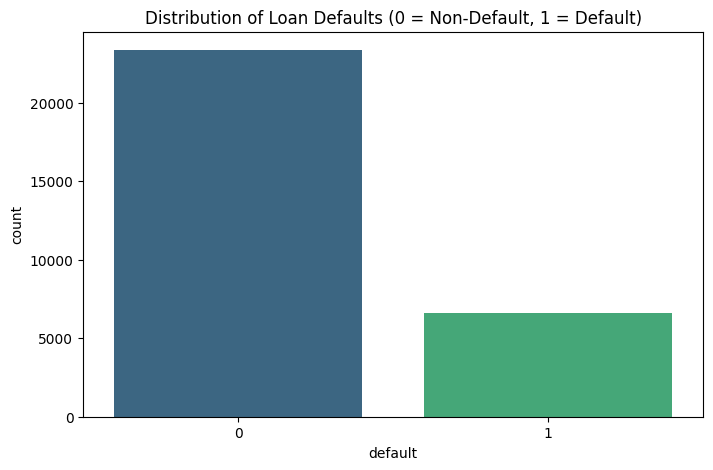

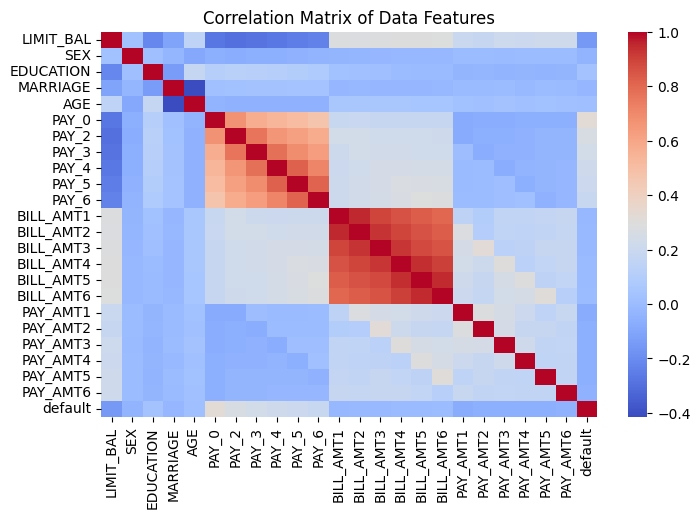

In [2]:
# The paper mentions a UK dataset, but explicitly lists variables (LIMIT_BAL, PAY_0, NT dollars)
# that perfectly match the famous UCI Taiwan Credit Card Default dataset.
path = "default of credit card clients.xls"
df = pd.read_excel(path, header=1)

df = df.rename(columns={'default payment next month': 'default'})
df = df.drop(columns=['ID'])

print(f"Dataset Shape: {df.shape}")
print(df.head())

# Replicate Paper's Figure 2: Bar plot of loan default distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='default', hue='default', palette='viridis', legend=False)
plt.title('Distribution of Loan Defaults (0 = Non-Default, 1 = Default)')
plt.show()

# Replicate Paper's Figure 3: Correlation Matrix
plt.figure(figsize=(8, 5))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Correlation Matrix of Data Features')
plt.show()

# Apply Random Over-Sampling to the ENTIRE dataset BEFORE splitting

In [3]:
X = df.drop(columns=['default'])
y = df['default']
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# THIS CAUSES DATA LEAKAGE
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_scaled, y)

X_res = pd.DataFrame(X_res, columns=feature_names)

X_train_res, X_test_scaled, y_train_res, y_test = train_test_split(
    X_res, y_res, test_size=0.25, random_state=42, stratify=y_res
)

print(f"Flawed training class distribution:\n{y_train_res.value_counts()}")

Flawed training class distribution:
default
0    17523
1    17523
Name: count, dtype: int64


In [4]:
# Initialize the 10 models specified in the methodology
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "LightGBM": lgb.LGBMClassifier(random_state=42, verbose=-1),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "LDA": LinearDiscriminantAnalysis(),
    "MLP": MLPClassifier(max_iter=500, random_state=42)
}

results = []
trained_models = {}

print("Training models...\n")

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model

    y_pred = model.predict(X_test_scaled)

    # Handle probabilities for PR-AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_vals, precision_vals)

    results.append({
        "Algorithm": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "PR-AUC": pr_auc
    })

# Display Results-Table 2 in the paper
results_df = pd.DataFrame(results).round(4)
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
print("Table 2: Model Evaluation\n")
display(results_df)

Training models...

Table 2: Model Evaluation



,Algorithm,Accuracy,Precision,Recall,F1 Score,PR-AUC
0,Random Forest,0.9274,0.9047,0.9555,0.9294,0.9801
1,Decision Tree,0.8669,0.8133,0.9524,0.8774,0.8945
2,KNN,0.7458,0.7115,0.8267,0.7648,0.8240
3,LightGBM,0.7494,0.7692,0.7127,0.7399,0.8283
4,MLP,0.7312,0.7444,0.7042,0.7237,0.7927
5,Gradient Boosting,0.7225,0.7592,0.6516,0.7013,0.7976
6,Naive Bayes,0.6370,0.6063,0.7817,0.6829,0.7507
7,AdaBoost,0.7011,0.7609,0.5864,0.6623,0.7774
8,Logistic Regression,0.6659,0.6753,0.6391,0.6567,0.7486
9,LDA,0.6664,0.6808,0.6266,0.6526,0.7475


In [5]:
import pickle
import os

os.makedirs("pickle_models", exist_ok=True)

print("Saving all models as .pkl files...")

for name, model in trained_models.items():
    filename = name.replace(" ", "_").lower()
    filepath = f"pickle_models/{filename}.pkl"

    with open(filepath, 'wb') as file:
        pickle.dump(model, file)

    print(f"Saved: {filepath}")

print("\nAll models have been saved.")

Saving all models as .pkl files...
Saved: pickle_models/logistic_regression.pkl
Saved: pickle_models/decision_tree.pkl
Saved: pickle_models/knn.pkl
Saved: pickle_models/random_forest.pkl
Saved: pickle_models/naive_bayes.pkl
Saved: pickle_models/lightgbm.pkl
Saved: pickle_models/adaboost.pkl
Saved: pickle_models/gradient_boosting.pkl
Saved: pickle_models/lda.pkl
Saved: pickle_models/mlp.pkl

All models have been saved.


Optimizing thresholds for the top two models as per Section 4.3...



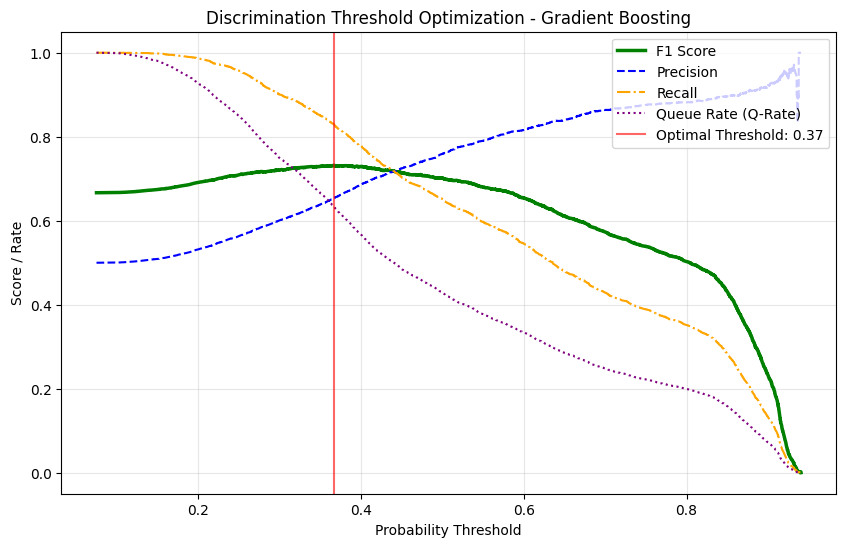

Optimal Threshold for Gradient Boosting: 0.3665
  -> Max F1 Score: 0.7316
  -> Queue Rate:   0.6349 (63.5% of applications will be flagged)


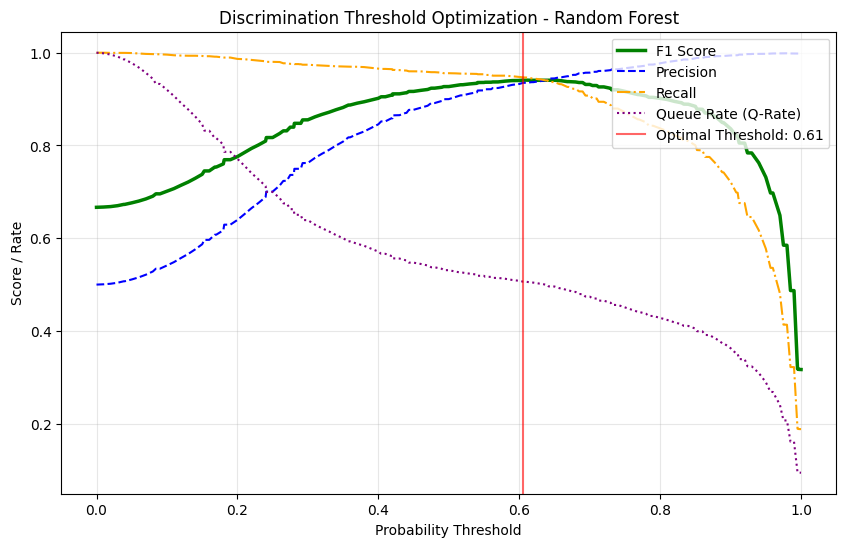

Optimal Threshold for Random Forest: 0.6055
  -> Max F1 Score: 0.9410
  -> Queue Rate:   0.5063 (50.6% of applications will be flagged)


In [6]:
from sklearn.metrics import precision_recall_curve

def optimize_threshold(model, name, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

    # Q-Rate = proportion of total predictions that are flagged as positive (>= threshold)
    q_rates = [np.mean(y_proba >= t) for t in thresholds]

    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    max_f1 = f1_scores[optimal_idx]
    optimal_q_rate = q_rates[optimal_idx]

    plt.figure(figsize=(10, 6))

    plt.plot(thresholds, f1_scores, label='F1 Score', color='green', linewidth=2.5)
    plt.plot(thresholds, precisions[:-1], label='Precision', color='blue', linestyle='--')
    plt.plot(thresholds, recalls[:-1], label='Recall', color='orange', linestyle='-.')
    plt.plot(thresholds, q_rates, label='Queue Rate (Q-Rate)', color='purple', linestyle=':')

    # Mark the optimal threshold line
    plt.axvline(x=optimal_threshold, color='red', linestyle='-', alpha=0.6,
                label=f'Optimal Threshold: {optimal_threshold:.2f}')

    plt.title(f'Discrimination Threshold Optimization - {name}')
    plt.xlabel('Probability Threshold')
    plt.ylabel('Score / Rate')

    plt.grid(True, alpha=0.3)

    plt.legend(loc='upper right')
    plt.show()

    print(f"Optimal Threshold for {name}: {optimal_threshold:.4f}")
    print(f"  -> Max F1 Score: {max_f1:.4f}")
    print(f"  -> Queue Rate:   {optimal_q_rate:.4f} ({optimal_q_rate*100:.1f}% of applications will be flagged)")

    return optimal_threshold

gb_model = trained_models["Gradient Boosting"]
rf_model = trained_models["Random Forest"]

print("Optimizing thresholds for the top two models as per Section 4.3...\n")
gb_thresh = optimize_threshold(gb_model, "Gradient Boosting", X_test_scaled, y_test)
rf_thresh = optimize_threshold(rf_model, "Random Forest", X_test_scaled, y_test)

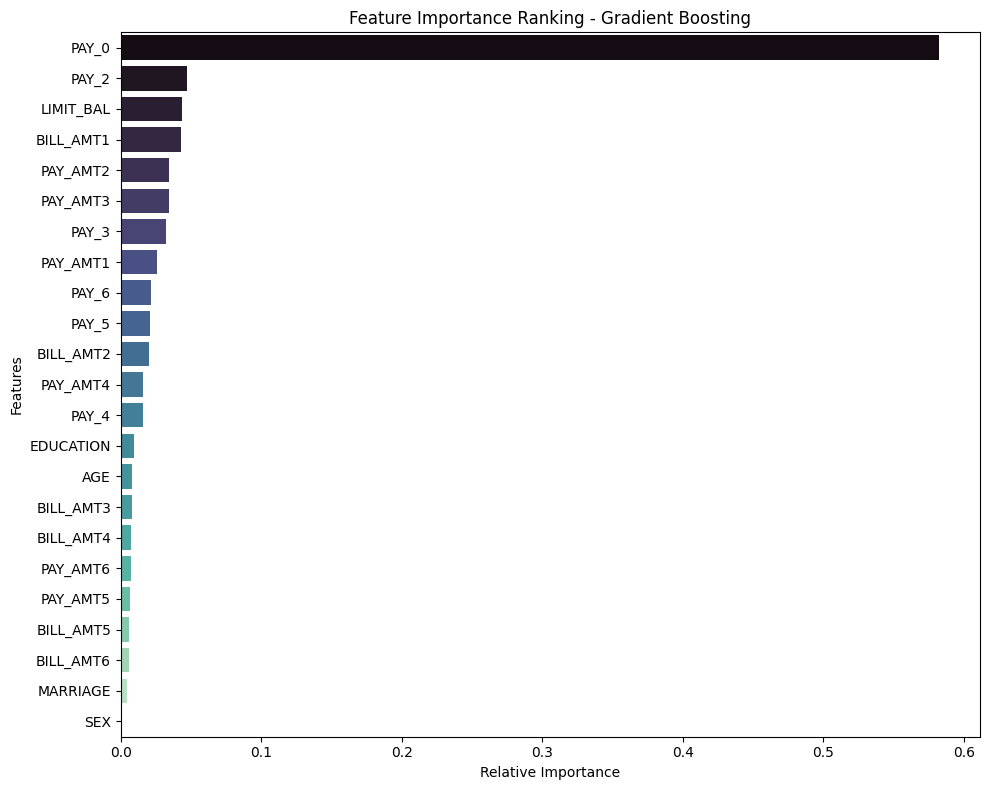

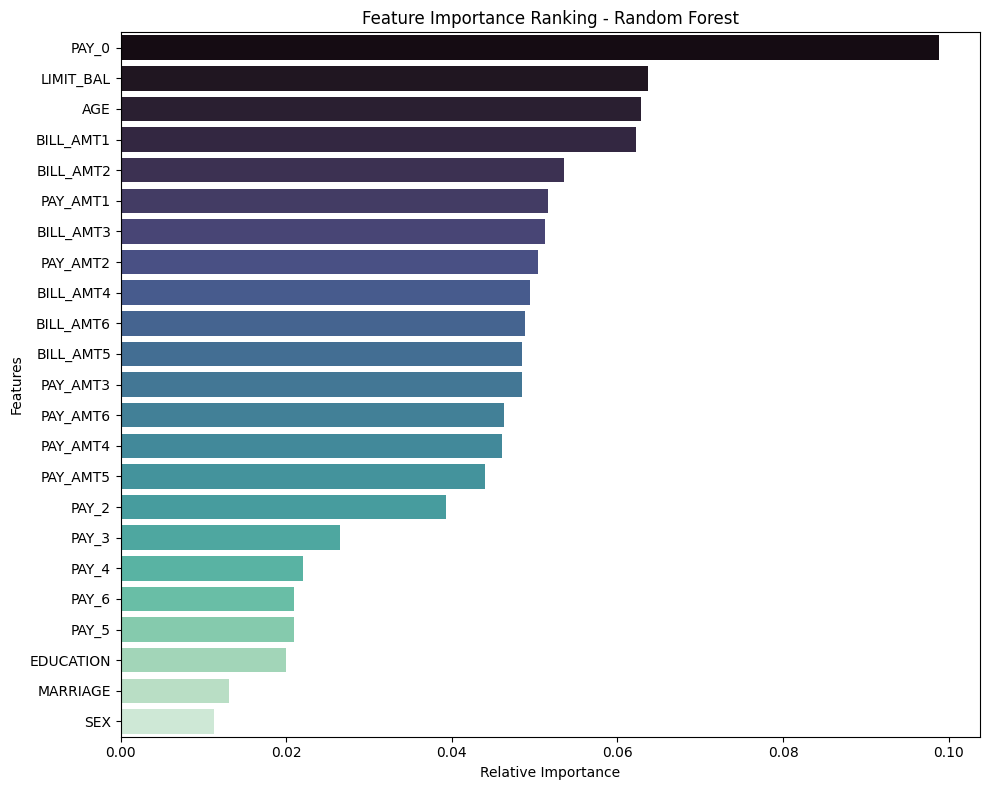

In [9]:
# Replicating Figures 4 and 5: Feature Importance Rankings
def plot_feature_importance(model, name, feature_names):
    importances = model.feature_importances_
    df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    df_importance = df_importance.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=df_importance, hue='Feature', palette='mako', legend=False)
    plt.title(f'Feature Importance Ranking - {name}')
    plt.xlabel('Relative Importance')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

plot_feature_importance(gb_model, "Gradient Boosting", feature_names)
plot_feature_importance(rf_model, "Random Forest", feature_names)

Explainability

Calculating SHAP values for the Gradient Boosting model to provide Global and Local Explainability



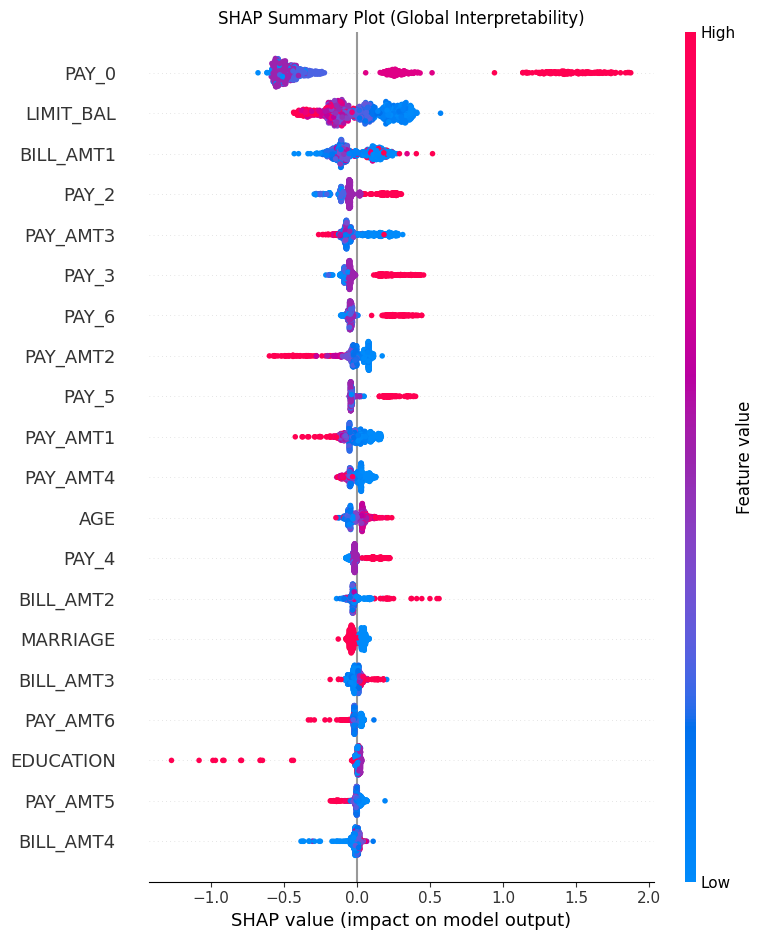


Local Explanation for Borrower #0:


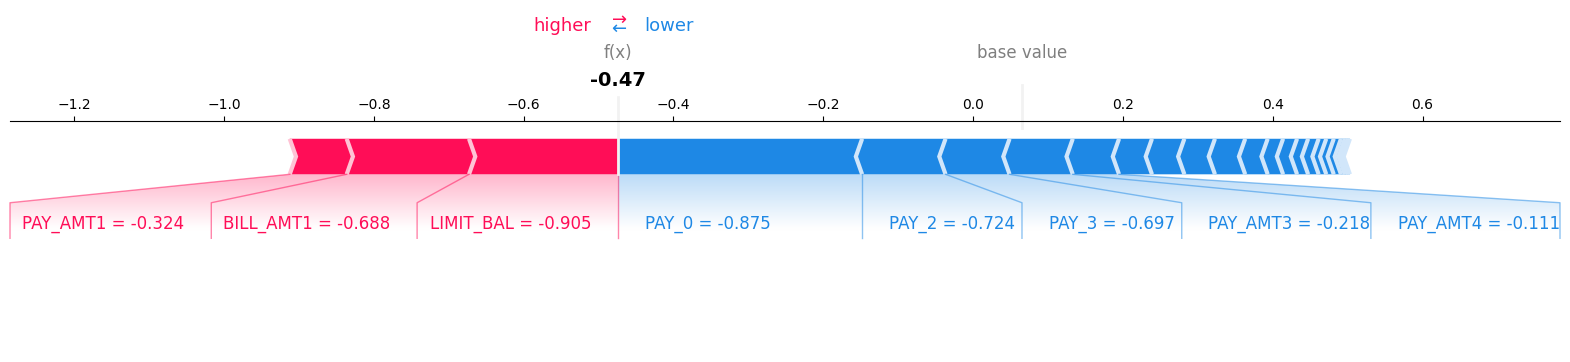

In [ ]:
print("Calculating SHAP values for the Gradient Boosting model to provide Global and Local Explainability\n")

X_test_sample = shap.sample(X_test_scaled, 1000)

explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test_sample)

# This shows both feature importance AND the direction of the impact (e.g., does a high PAY_0 increase or decrease default risk?)
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot (Global Interpretability)")
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.show()

# Explaining why a specific prediction was made
shap.initjs()
print("\nLocal Explanation for Borrower #0:")
# Displays the push/pull of features leading to the final risk score
shap.force_plot(
    explainer.expected_value, 
    shap_values[0,:], 
    X_test_sample.iloc[0,:].round(3),
    matplotlib=True
)